In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import datasets, transforms
from torch.utils.data import DataLoader, Dataset
import numpy as np
import wandb
import matplotlib.pyplot as plt
import os

class CIFAR10Colorization(Dataset):
    def __init__(self, train=True):
        self.dataset = datasets.CIFAR10(root="./data", train=train, download=True)
        self.centroids = np.load("color_centroids.npy").astype(np.float32) / 255.0  # 24x3
        self.to_gray = transforms.Grayscale(num_output_channels=1)
        self.to_tensor = transforms.ToTensor()

    def __len__(self):
        return len(self.dataset)

    def __getitem__(self, idx):
        img, _ = self.dataset[idx]
        img_rgb = np.array(img).astype(np.float32) / 255.0

        gray = self.to_gray(img)
        gray = self.to_tensor(gray)

        pixels = img_rgb.reshape(-1, 3)
        dist = np.linalg.norm(pixels[:, None, :] - self.centroids[None, :, :], axis=2)
        label_map = np.argmin(dist, axis=1).reshape(32, 32)
        label_map = torch.from_numpy(label_map).long()

        return gray, label_map


# Fixed datasets (so sweeps reuse them)
train_dataset = CIFAR10Colorization(train=True)
val_dataset = CIFAR10Colorization(train=False)


class ColorizationCNN(nn.Module):
    def __init__(self, NIC=1, NF=16, NC=24, kernel_size=3):
        super().__init__()
        pad = kernel_size // 2
        self.encoder = nn.Sequential(
            nn.Conv2d(NIC, NF, kernel_size, padding=pad),
            nn.BatchNorm2d(NF),
            nn.ReLU(),
            nn.MaxPool2d(2),

            nn.Conv2d(NF, 2 * NF, kernel_size, padding=pad),
            nn.BatchNorm2d(2 * NF),
            nn.ReLU(),
            nn.MaxPool2d(2),

            nn.Conv2d(2 * NF, 4 * NF, kernel_size, padding=pad),
            nn.BatchNorm2d(4 * NF),
            nn.ReLU(),
            nn.MaxPool2d(2),
        )

        self.decoder = nn.Sequential(
            nn.ConvTranspose2d(4 * NF, 2 * NF, kernel_size=2, stride=2),
            nn.BatchNorm2d(2 * NF),
            nn.ReLU(),

            nn.ConvTranspose2d(2 * NF, NF, kernel_size=2, stride=2),
            nn.BatchNorm2d(NF),
            nn.ReLU(),

            nn.ConvTranspose2d(NF, 24, kernel_size=2, stride=2),
            nn.BatchNorm2d(24),
            nn.ReLU(),

            nn.Conv2d(24, 24, kernel_size=1)
        )

    def forward(self, x):
        return self.decoder(self.encoder(x))


def train():
    wandb.init(project="_image-colourisation-cifar10")
    config = wandb.config

    device = "cuda" if torch.cuda.is_available() else "cpu"

    train_loader = DataLoader(train_dataset, batch_size=config.batch_size, shuffle=True)
    val_loader = DataLoader(val_dataset, batch_size=config.batch_size)

    model = ColorizationCNN(NIC=1, NF=config.NF, kernel_size=config.kernel_size).to(device)
    criterion = nn.CrossEntropyLoss()

    if config.optimizer == "adam":
        optimizer = optim.Adam(model.parameters(), lr=config.lr)
    else:
        optimizer = optim.SGD(model.parameters(), lr=config.lr, momentum=0.9)

    best_val_loss = float("inf")
    save_path = f"best_model_{wandb.run.name}.pth"

    # ---- Training loop ----
    for epoch in range(25):
        model.train()
        total_train_loss = 0

        for gray, label_map in train_loader:
            gray, label_map = gray.to(device), label_map.to(device)
            optimizer.zero_grad()
            logits = model(gray)
            loss = criterion(logits, label_map)
            loss.backward()
            optimizer.step()
            total_train_loss += loss.item()

        # ---- Validation ----
        model.eval()
        total_val_loss = 0
        with torch.no_grad():
            for gray, label_map in val_loader:
                gray, label_map = gray.to(device), label_map.to(device)
                logits = model(gray)
                loss = criterion(logits, label_map)
                total_val_loss += loss.item()

        avg_train_loss = total_train_loss / len(train_loader)
        avg_val_loss = total_val_loss / len(val_loader)

        # Log & print
        wandb.log({
            "epoch": epoch + 1,
            "train_loss": avg_train_loss,
            "val_loss": avg_val_loss,
        })
        print(f"Epoch [{epoch+1}/25] | Train Loss: {avg_train_loss:.4f} | Val Loss: {avg_val_loss:.4f}")

        if avg_val_loss < best_val_loss:
            best_val_loss = avg_val_loss
            torch.save(model.state_dict(), save_path)

    # ---- Post-training visualization ----
    model.load_state_dict(torch.load(save_path))
    model.eval()
    centroids = np.load("color_centroids.npy") / 255.0

    def decode_centroid_map(pred_map):
        return np.clip(centroids[pred_map], 0, 1)

    gray_batch, label_batch = next(iter(val_loader))
    gray_batch = gray_batch.to(device)
    with torch.no_grad():
        preds = torch.argmax(model(gray_batch), dim=1).cpu().numpy()

    fig, axs = plt.subplots(5, 3, figsize=(6, 12))
    for i in range(5):
        gray_img = gray_batch[i][0].cpu().numpy()
        pred_color = decode_centroid_map(preds[i])
        gt_color = decode_centroid_map(label_batch[i].numpy())

        axs[i, 0].imshow(gray_img, cmap="gray")
        axs[i, 1].imshow(pred_color)
        axs[i, 2].imshow(gt_color)

        axs[i, 0].set_title("Gray")
        axs[i, 1].set_title("Predicted")
        axs[i, 2].set_title("Ground Truth")
        for j in range(3):
            axs[i, j].axis("off")

    plt.tight_layout()
    plt.show()

    # Log some example images to wandb
    examples = []
    for i in range(3):
        gray_img = gray_batch[i][0].cpu().numpy()
        pred_color = decode_centroid_map(preds[i])
        gt_color = decode_centroid_map(label_batch[i].numpy())

        examples.append(wandb.Image(
            np.concatenate([np.stack([gray_img]*3, axis=2), pred_color, gt_color], axis=1),
            caption=f"Gray | Predicted | Ground Truth"
        ))

    wandb.log({"examples": examples, "best_val_loss": best_val_loss})
    wandb.save(save_path)
    wandb.finish()



Files already downloaded and verified
Files already downloaded and verified


wandb: Using wandb-core as the SDK backend. Please refer to https://wandb.me/wandb-core for more information.


Create sweep with ID: 0hdeee43
Sweep URL: https://wandb.ai/yogeswari05-iiit-hyderabad/_image-colourisation-cifar10/sweeps/0hdeee43


wandb: Agent Starting Run: zl5bsjpn with config:
wandb: 	NF: 16
wandb: 	batch_size: 128
wandb: 	kernel_size: 3
wandb: 	lr: 0.001
wandb: 	optimizer: sgd
wandb: Currently logged in as: yogeswari05 (yogeswari05-iiit-hyderabad). Use `wandb login --relogin` to force relogin
wandb: WARNING Ignored wandb.init() arg project when running a sweep.


Epoch [1/25] | Train Loss: 3.1346 | Val Loss: 3.0201
Epoch [2/25] | Train Loss: 2.9398 | Val Loss: 2.8815
Epoch [3/25] | Train Loss: 2.8263 | Val Loss: 2.7846
Epoch [4/25] | Train Loss: 2.7377 | Val Loss: 2.7003
Epoch [5/25] | Train Loss: 2.6593 | Val Loss: 2.6225
Epoch [6/25] | Train Loss: 2.5759 | Val Loss: 2.5313
Epoch [7/25] | Train Loss: 2.4892 | Val Loss: 2.4504
Epoch [8/25] | Train Loss: 2.4142 | Val Loss: 2.3805
Epoch [9/25] | Train Loss: 2.3521 | Val Loss: 2.3243
Epoch [10/25] | Train Loss: 2.3018 | Val Loss: 2.2788
Epoch [11/25] | Train Loss: 2.2604 | Val Loss: 2.2378
Epoch [12/25] | Train Loss: 2.2256 | Val Loss: 2.2060
Epoch [13/25] | Train Loss: 2.1966 | Val Loss: 2.1786
Epoch [14/25] | Train Loss: 2.1724 | Val Loss: 2.1554
Epoch [15/25] | Train Loss: 2.1512 | Val Loss: 2.1351
Epoch [16/25] | Train Loss: 2.1339 | Val Loss: 2.1176
Epoch [17/25] | Train Loss: 2.1173 | Val Loss: 2.1018
Epoch [18/25] | Train Loss: 2.1036 | Val Loss: 2.0884
Epoch [19/25] | Train Loss: 2.0915 | 

C:\Users\yeduk\AppData\Local\Temp\ipykernel_7784\1900195944.py:142: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model.load_state_dict(torch.load(save_path))


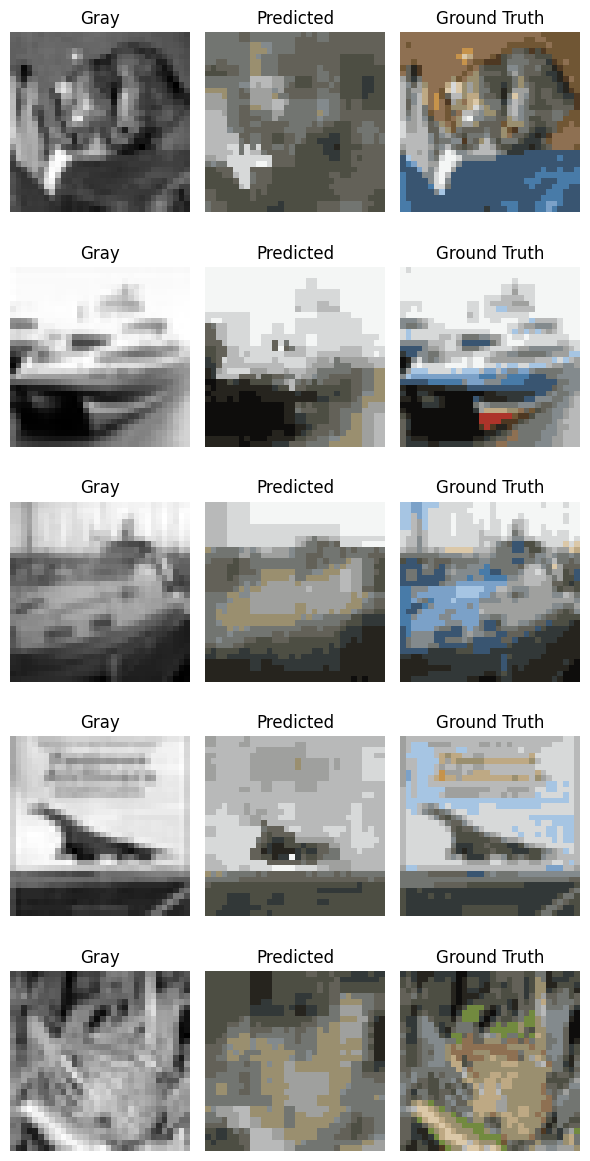

best_val_loss,▁
epoch,▁▁▂▂▂▂▃▃▃▄▄▄▅▅▅▅▆▆▆▇▇▇▇██
train_loss,█▇▆▅▅▄▄▃▃▃▂▂▂▂▂▂▂▁▁▁▁▁▁▁▁
val_loss,█▇▆▆▅▅▄▄▃▃▃▂▂▂▂▂▂▁▁▁▁▁▁▁▁
best_val_loss,2.01831
epoch,25
train_loss,2.03296
val_loss,2.01831


wandb: Agent Starting Run: mrw0upi4 with config:
wandb: 	NF: 8
wandb: 	batch_size: 128
wandb: 	kernel_size: 5
wandb: 	lr: 0.001
wandb: 	optimizer: adam
wandb: WARNING Ignored wandb.init() arg project when running a sweep.


Epoch [1/25] | Train Loss: 2.3539 | Val Loss: 2.0468
Epoch [2/25] | Train Loss: 1.9733 | Val Loss: 1.9178
Epoch [3/25] | Train Loss: 1.8997 | Val Loss: 1.8628
Epoch [4/25] | Train Loss: 1.8605 | Val Loss: 1.8319
Epoch [5/25] | Train Loss: 1.8354 | Val Loss: 1.8291
Epoch [6/25] | Train Loss: 1.8169 | Val Loss: 1.7872
Epoch [7/25] | Train Loss: 1.8035 | Val Loss: 1.7703
Epoch [8/25] | Train Loss: 1.7921 | Val Loss: 1.7610
Epoch [9/25] | Train Loss: 1.7763 | Val Loss: 1.7964
Epoch [10/25] | Train Loss: 1.7664 | Val Loss: 1.7501
Epoch [11/25] | Train Loss: 1.7583 | Val Loss: 1.7433
Epoch [12/25] | Train Loss: 1.7501 | Val Loss: 1.7585
Epoch [13/25] | Train Loss: 1.7427 | Val Loss: 1.7281
Epoch [14/25] | Train Loss: 1.7325 | Val Loss: 1.7550
Epoch [15/25] | Train Loss: 1.7263 | Val Loss: 1.7561
Epoch [16/25] | Train Loss: 1.7168 | Val Loss: 1.6858
Epoch [17/25] | Train Loss: 1.7104 | Val Loss: 1.6926
Epoch [18/25] | Train Loss: 1.7060 | Val Loss: 1.6936
Epoch [19/25] | Train Loss: 1.7018 | 

C:\Users\yeduk\AppData\Local\Temp\ipykernel_7784\1900195944.py:142: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model.load_state_dict(torch.load(save_path))


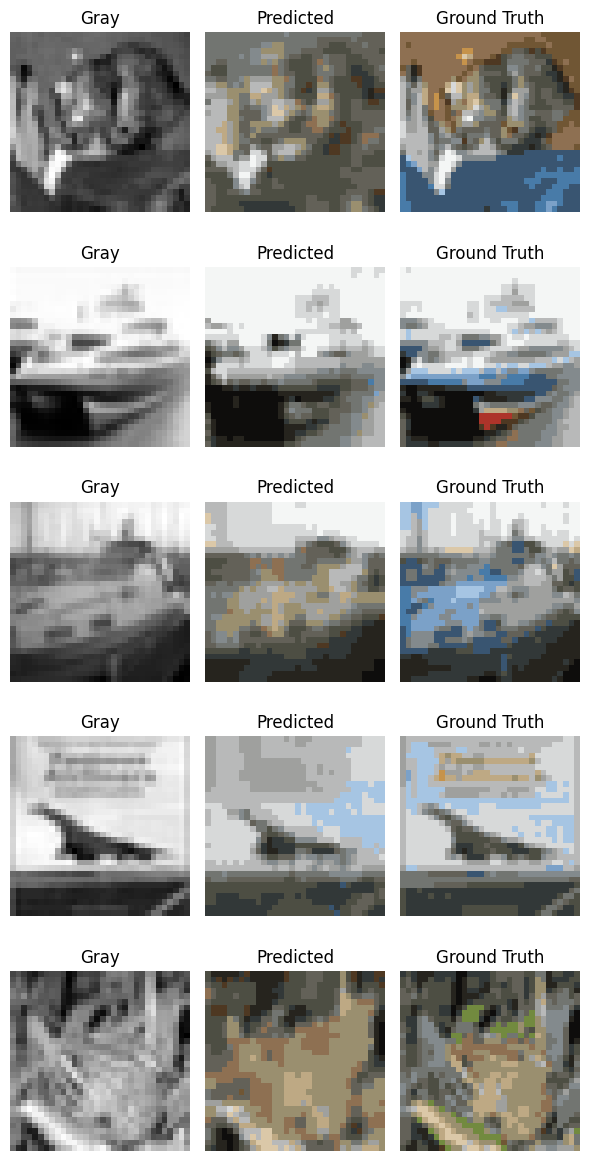

best_val_loss,▁
epoch,▁▁▂▂▂▂▃▃▃▄▄▄▅▅▅▅▆▆▆▇▇▇▇██
train_loss,█▄▃▃▃▂▂▂▂▂▂▂▂▂▂▁▁▁▁▁▁▁▁▁▁
val_loss,█▆▅▄▄▃▃▃▃▃▂▃▂▃▃▁▁▁▁▁▁▁▂▁▁
best_val_loss,1.66827
epoch,25
train_loss,1.67505
val_loss,1.67321


wandb: Sweep Agent: Waiting for job.
wandb: Job received.
wandb: Agent Starting Run: 6ij2ecu7 with config:
wandb: 	NF: 32
wandb: 	batch_size: 128
wandb: 	kernel_size: 3
wandb: 	lr: 0.0001
wandb: 	optimizer: sgd
wandb: WARNING Ignored wandb.init() arg project when running a sweep.


Epoch [1/25] | Train Loss: 3.2277 | Val Loss: 3.2121
Epoch [2/25] | Train Loss: 3.1974 | Val Loss: 3.1834
Epoch [3/25] | Train Loss: 3.1692 | Val Loss: 3.1567
Epoch [4/25] | Train Loss: 3.1420 | Val Loss: 3.1298
Epoch [5/25] | Train Loss: 3.1153 | Val Loss: 3.1037
Epoch [6/25] | Train Loss: 3.0888 | Val Loss: 3.0773
Epoch [7/25] | Train Loss: 3.0626 | Val Loss: 3.0510
Epoch [8/25] | Train Loss: 3.0372 | Val Loss: 3.0274
Epoch [9/25] | Train Loss: 3.0131 | Val Loss: 3.0056
Epoch [10/25] | Train Loss: 2.9903 | Val Loss: 2.9819
Epoch [11/25] | Train Loss: 2.9688 | Val Loss: 2.9606
Epoch [12/25] | Train Loss: 2.9480 | Val Loss: 2.9425
Epoch [13/25] | Train Loss: 2.9279 | Val Loss: 2.9200
Epoch [14/25] | Train Loss: 2.9081 | Val Loss: 2.9010
Epoch [15/25] | Train Loss: 2.8884 | Val Loss: 2.8812
Epoch [16/25] | Train Loss: 2.8691 | Val Loss: 2.8622
Epoch [17/25] | Train Loss: 2.8496 | Val Loss: 2.8423
Epoch [18/25] | Train Loss: 2.8303 | Val Loss: 2.8226
Epoch [19/25] | Train Loss: 2.8112 | 

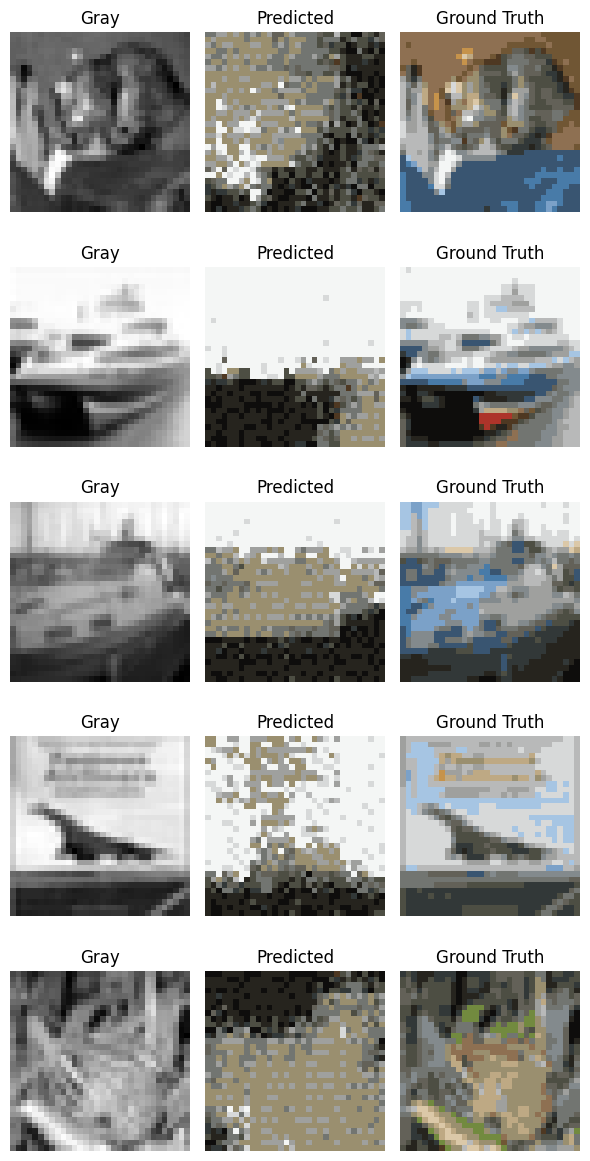

best_val_loss,▁
epoch,▁▁▂▂▂▂▃▃▃▄▄▄▅▅▅▅▆▆▆▇▇▇▇██
train_loss,██▇▇▆▆▆▅▅▅▅▄▄▄▃▃▃▃▂▂▂▂▁▁▁
val_loss,██▇▇▇▆▆▅▅▅▅▄▄▄▃▃▃▃▂▂▂▂▁▁▁
best_val_loss,2.70245
epoch,25
train_loss,2.70807
val_loss,2.70245


wandb: Agent Starting Run: e5y326yi with config:
wandb: 	NF: 16
wandb: 	batch_size: 128
wandb: 	kernel_size: 5
wandb: 	lr: 0.003
wandb: 	optimizer: adam
wandb: WARNING Ignored wandb.init() arg project when running a sweep.


Epoch [1/25] | Train Loss: 2.0560 | Val Loss: 1.8134
Epoch [2/25] | Train Loss: 1.7584 | Val Loss: 1.7776
Epoch [3/25] | Train Loss: 1.7012 | Val Loss: 1.6723
Epoch [4/25] | Train Loss: 1.6578 | Val Loss: 1.7453
Epoch [5/25] | Train Loss: 1.6397 | Val Loss: 1.6339
Epoch [6/25] | Train Loss: 1.6136 | Val Loss: 1.6460
Epoch [7/25] | Train Loss: 1.6009 | Val Loss: 1.6122
Epoch [8/25] | Train Loss: 1.5831 | Val Loss: 1.6332
Epoch [9/25] | Train Loss: 1.5760 | Val Loss: 1.7539
Epoch [10/25] | Train Loss: 1.5619 | Val Loss: 1.5542
Epoch [11/25] | Train Loss: 1.5553 | Val Loss: 1.6439
Epoch [12/25] | Train Loss: 1.5537 | Val Loss: 1.5919
Epoch [13/25] | Train Loss: 1.5448 | Val Loss: 1.6491
Epoch [14/25] | Train Loss: 1.5408 | Val Loss: 1.5710
Epoch [15/25] | Train Loss: 1.5296 | Val Loss: 1.5551
Epoch [16/25] | Train Loss: 1.5289 | Val Loss: 1.5514
Epoch [17/25] | Train Loss: 1.5225 | Val Loss: 1.5100
Epoch [18/25] | Train Loss: 1.5187 | Val Loss: 1.5216
Epoch [19/25] | Train Loss: 1.5181 | 

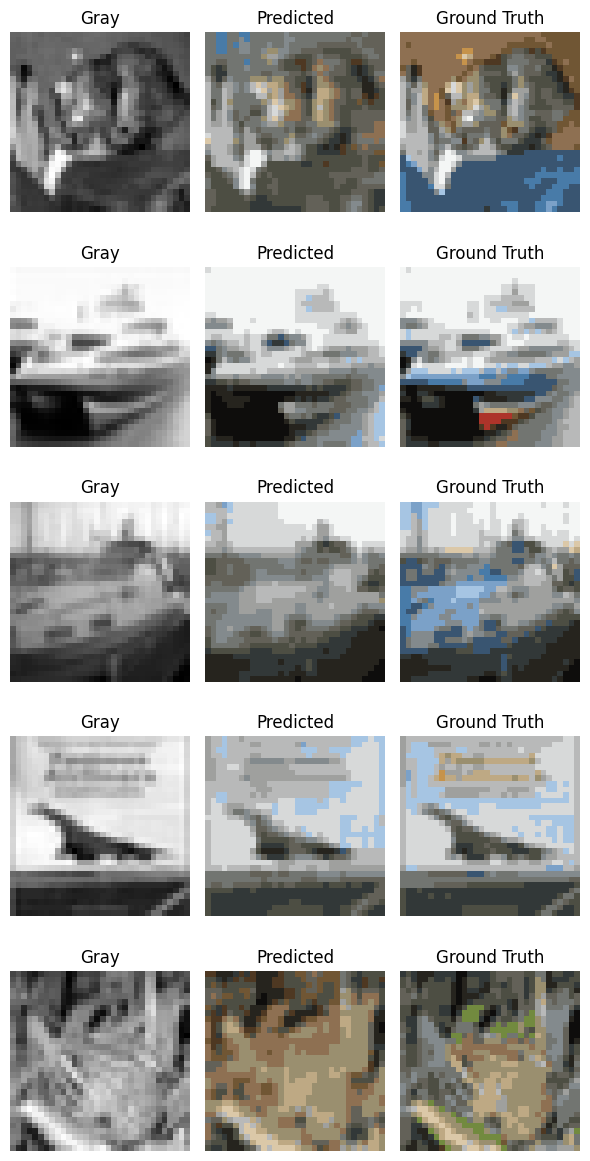

best_val_loss,▁
epoch,▁▁▂▂▂▂▃▃▃▄▄▄▅▅▅▅▆▆▆▇▇▇▇██
train_loss,█▄▄▃▃▂▂▂▂▂▂▂▂▂▁▁▁▁▁▁▁▁▁▁▁
val_loss,█▇▅▇▄▄▄▄▇▂▄▃▄▃▂▂▁▂▅▂▂▂▁▁▃
best_val_loss,1.49516
epoch,25
train_loss,1.49554
val_loss,1.57433


wandb: Agent Starting Run: 2hpf47z5 with config:
wandb: 	NF: 8
wandb: 	batch_size: 64
wandb: 	kernel_size: 5
wandb: 	lr: 0.003
wandb: 	optimizer: adam
wandb: WARNING Ignored wandb.init() arg project when running a sweep.


Epoch [1/25] | Train Loss: 2.0914 | Val Loss: 2.0287
Epoch [2/25] | Train Loss: 1.8704 | Val Loss: 1.9060
Epoch [3/25] | Train Loss: 1.8255 | Val Loss: 1.8048
Epoch [4/25] | Train Loss: 1.8030 | Val Loss: 1.7497
Epoch [5/25] | Train Loss: 1.7737 | Val Loss: 1.7946
Epoch [6/25] | Train Loss: 1.7606 | Val Loss: 1.7177
Epoch [7/25] | Train Loss: 1.7521 | Val Loss: 1.7186
Epoch [8/25] | Train Loss: 1.7378 | Val Loss: 1.7358
Epoch [9/25] | Train Loss: 1.7271 | Val Loss: 1.6885
Epoch [10/25] | Train Loss: 1.7189 | Val Loss: 1.6965
Epoch [11/25] | Train Loss: 1.7135 | Val Loss: 1.7200
Epoch [12/25] | Train Loss: 1.7046 | Val Loss: 1.7557
Epoch [13/25] | Train Loss: 1.7007 | Val Loss: 1.6663
Epoch [14/25] | Train Loss: 1.6941 | Val Loss: 1.7913
Epoch [15/25] | Train Loss: 1.6840 | Val Loss: 1.6459
Epoch [16/25] | Train Loss: 1.6789 | Val Loss: 1.8461
Epoch [17/25] | Train Loss: 1.6777 | Val Loss: 1.7512
Epoch [18/25] | Train Loss: 1.6763 | Val Loss: 1.7105
Epoch [19/25] | Train Loss: 1.6716 | 

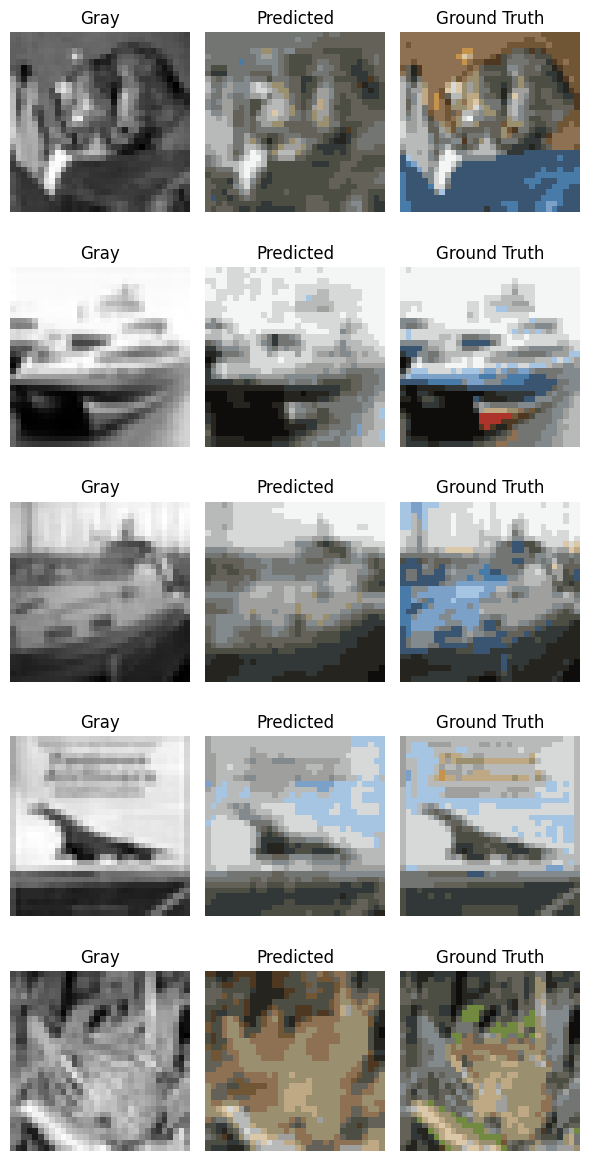

best_val_loss,▁
epoch,▁▁▂▂▂▂▃▃▃▄▄▄▅▅▅▅▆▆▆▇▇▇▇██
train_loss,█▄▄▃▃▃▂▂▂▂▂▂▂▂▁▁▁▁▁▁▁▁▁▁▁
val_loss,█▆▄▃▄▃▃▃▂▂▃▃▂▄▂▅▃▃▁▁▁▁▃▁▁
best_val_loss,1.61555
epoch,25
train_loss,1.66159
val_loss,1.62939


wandb: Agent Starting Run: v2helu3m with config:
wandb: 	NF: 16
wandb: 	batch_size: 128
wandb: 	kernel_size: 3
wandb: 	lr: 0.0003
wandb: 	optimizer: sgd
wandb: WARNING Ignored wandb.init() arg project when running a sweep.


Epoch [1/25] | Train Loss: 3.2091 | Val Loss: 3.1687
Epoch [2/25] | Train Loss: 3.1282 | Val Loss: 3.0853
Epoch [3/25] | Train Loss: 3.0486 | Val Loss: 3.0108
Epoch [4/25] | Train Loss: 2.9855 | Val Loss: 2.9575
Epoch [5/25] | Train Loss: 2.9394 | Val Loss: 2.9168
Epoch [6/25] | Train Loss: 2.9012 | Val Loss: 2.8815
Epoch [7/25] | Train Loss: 2.8669 | Val Loss: 2.8474
Epoch [8/25] | Train Loss: 2.8347 | Val Loss: 2.8168
Epoch [9/25] | Train Loss: 2.8051 | Val Loss: 2.7895
Epoch [10/25] | Train Loss: 2.7776 | Val Loss: 2.7619
Epoch [11/25] | Train Loss: 2.7526 | Val Loss: 2.7378
Epoch [12/25] | Train Loss: 2.7287 | Val Loss: 2.7156
Epoch [13/25] | Train Loss: 2.7064 | Val Loss: 2.6936
Epoch [14/25] | Train Loss: 2.6845 | Val Loss: 2.6721
Epoch [15/25] | Train Loss: 2.6622 | Val Loss: 2.6485
Epoch [16/25] | Train Loss: 2.6384 | Val Loss: 2.6249
Epoch [17/25] | Train Loss: 2.6127 | Val Loss: 2.5995
Epoch [18/25] | Train Loss: 2.5857 | Val Loss: 2.5700
Epoch [19/25] | Train Loss: 2.5570 | 

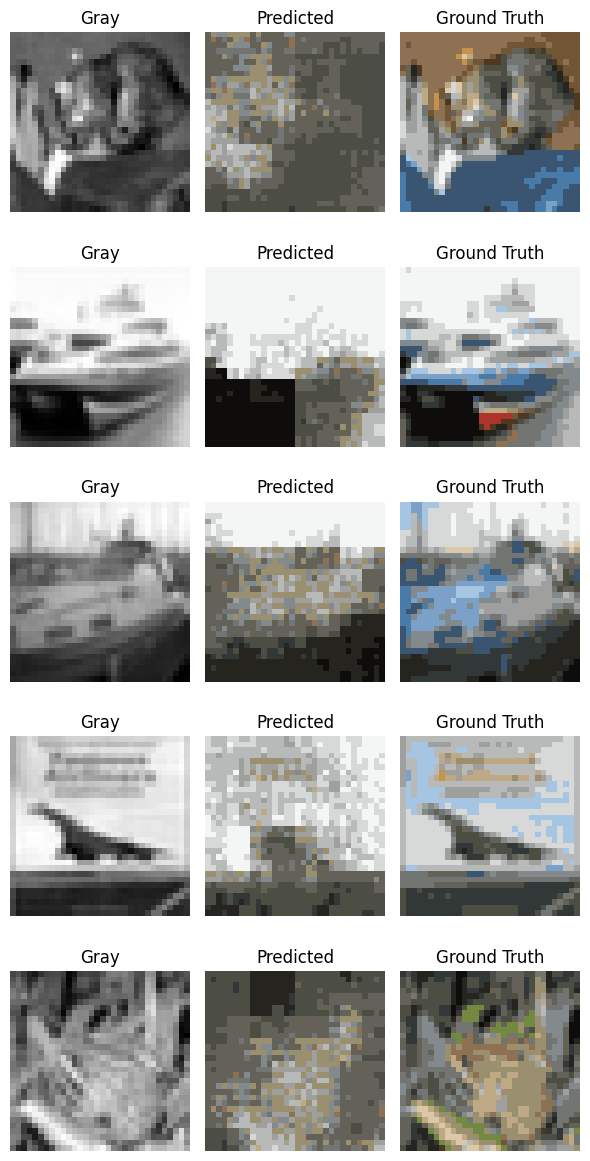

best_val_loss,▁
epoch,▁▁▂▂▂▂▃▃▃▄▄▄▅▅▅▅▆▆▆▇▇▇▇██
train_loss,█▇▇▆▆▅▅▅▄▄▄▄▄▃▃▃▃▃▂▂▂▂▁▁▁
val_loss,█▇▇▆▆▅▅▅▅▄▄▄▄▄▃▃▃▃▂▂▂▂▁▁▁
best_val_loss,2.39382
epoch,25
train_loss,2.40543
val_loss,2.39382


wandb: Agent Starting Run: f861i7dn with config:
wandb: 	NF: 32
wandb: 	batch_size: 128
wandb: 	kernel_size: 5
wandb: 	lr: 0.003
wandb: 	optimizer: sgd
wandb: WARNING Ignored wandb.init() arg project when running a sweep.


Epoch [1/25] | Train Loss: 2.9456 | Val Loss: 2.7456
Epoch [2/25] | Train Loss: 2.5812 | Val Loss: 2.4365
Epoch [3/25] | Train Loss: 2.3235 | Val Loss: 2.2176
Epoch [4/25] | Train Loss: 2.1521 | Val Loss: 2.0885
Epoch [5/25] | Train Loss: 2.0482 | Val Loss: 1.9978
Epoch [6/25] | Train Loss: 1.9782 | Val Loss: 1.9367
Epoch [7/25] | Train Loss: 1.9247 | Val Loss: 1.8883
Epoch [8/25] | Train Loss: 1.8825 | Val Loss: 1.8527
Epoch [9/25] | Train Loss: 1.8494 | Val Loss: 1.8172
Epoch [10/25] | Train Loss: 1.8206 | Val Loss: 1.7896
Epoch [11/25] | Train Loss: 1.7957 | Val Loss: 1.7668
Epoch [12/25] | Train Loss: 1.7739 | Val Loss: 1.7462
Epoch [13/25] | Train Loss: 1.7561 | Val Loss: 1.7437
Epoch [14/25] | Train Loss: 1.7372 | Val Loss: 1.7053
Epoch [15/25] | Train Loss: 1.7205 | Val Loss: 1.6921
Epoch [16/25] | Train Loss: 1.7079 | Val Loss: 1.6759
Epoch [17/25] | Train Loss: 1.6944 | Val Loss: 1.6641
Epoch [18/25] | Train Loss: 1.6820 | Val Loss: 1.6572
Epoch [19/25] | Train Loss: 1.6690 | 

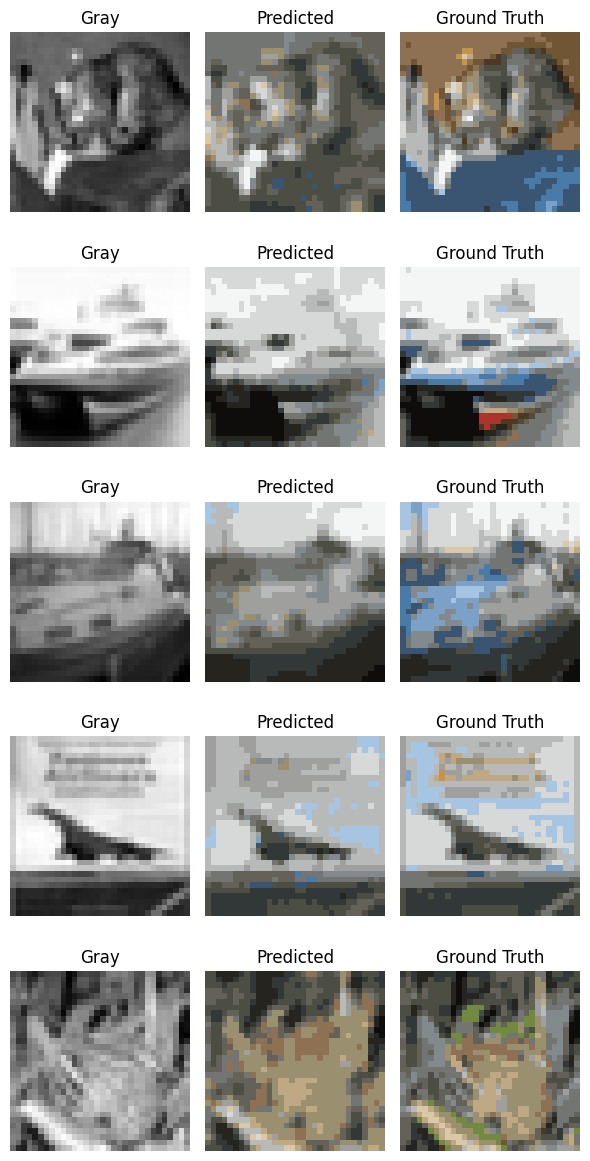

best_val_loss,▁
epoch,▁▁▂▂▂▂▃▃▃▄▄▄▅▅▅▅▆▆▆▇▇▇▇██
train_loss,█▆▅▄▃▃▃▂▂▂▂▂▂▂▂▂▂▁▁▁▁▁▁▁▁
val_loss,█▆▅▄▄▃▃▃▂▂▂▂▂▂▂▂▂▁▁▁▁▁▂▁▁
best_val_loss,1.58043
epoch,25
train_loss,1.59704
val_loss,1.58043


wandb: Agent Starting Run: 75onrf3s with config:
wandb: 	NF: 8
wandb: 	batch_size: 32
wandb: 	kernel_size: 3
wandb: 	lr: 0.0001
wandb: 	optimizer: adam
wandb: WARNING Ignored wandb.init() arg project when running a sweep.


Epoch [1/25] | Train Loss: 2.6631 | Val Loss: 2.3552
Epoch [2/25] | Train Loss: 2.2871 | Val Loss: 2.1994
Epoch [3/25] | Train Loss: 2.1961 | Val Loss: 2.1354
Epoch [4/25] | Train Loss: 2.1514 | Val Loss: 2.0961
Epoch [5/25] | Train Loss: 2.1214 | Val Loss: 2.0687
Epoch [6/25] | Train Loss: 2.1037 | Val Loss: 2.0534
Epoch [7/25] | Train Loss: 2.0901 | Val Loss: 2.0375
Epoch [8/25] | Train Loss: 2.0795 | Val Loss: 2.0250
Epoch [9/25] | Train Loss: 2.0701 | Val Loss: 2.0163
Epoch [10/25] | Train Loss: 2.0646 | Val Loss: 2.0087
Epoch [11/25] | Train Loss: 2.0557 | Val Loss: 2.0052
Epoch [12/25] | Train Loss: 2.0494 | Val Loss: 1.9973
Epoch [13/25] | Train Loss: 2.0455 | Val Loss: 1.9888
Epoch [14/25] | Train Loss: 2.0423 | Val Loss: 1.9926
Epoch [15/25] | Train Loss: 2.0359 | Val Loss: 1.9848
Epoch [16/25] | Train Loss: 2.0324 | Val Loss: 1.9747
Epoch [17/25] | Train Loss: 2.0271 | Val Loss: 1.9762
Epoch [18/25] | Train Loss: 2.0246 | Val Loss: 1.9679
Epoch [19/25] | Train Loss: 2.0237 | 

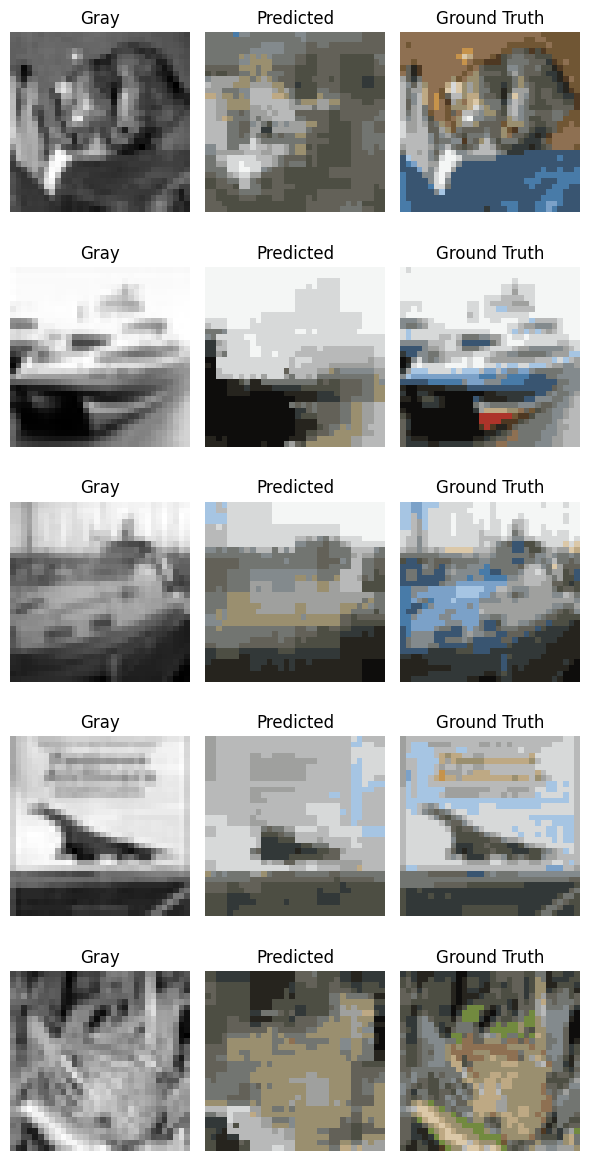

best_val_loss,▁
epoch,▁▁▂▂▂▂▃▃▃▄▄▄▅▅▅▅▆▆▆▇▇▇▇██
train_loss,█▄▃▃▂▂▂▂▂▂▂▂▁▁▁▁▁▁▁▁▁▁▁▁▁
val_loss,█▅▄▃▃▃▂▂▂▂▂▂▂▂▂▁▁▁▁▁▁▁▁▁▁
best_val_loss,1.95264
epoch,25
train_loss,2.0018
val_loss,1.95886


wandb: Agent Starting Run: 22kdr257 with config:
wandb: 	NF: 8
wandb: 	batch_size: 128
wandb: 	kernel_size: 3
wandb: 	lr: 0.0003
wandb: 	optimizer: sgd
wandb: WARNING Ignored wandb.init() arg project when running a sweep.


Epoch [1/25] | Train Loss: 3.2468 | Val Loss: 3.2074
Epoch [2/25] | Train Loss: 3.1779 | Val Loss: 3.1539
Epoch [3/25] | Train Loss: 3.1290 | Val Loss: 3.1081
Epoch [4/25] | Train Loss: 3.0812 | Val Loss: 3.0574
Epoch [5/25] | Train Loss: 3.0281 | Val Loss: 3.0041
Epoch [6/25] | Train Loss: 2.9753 | Val Loss: 2.9545
Epoch [7/25] | Train Loss: 2.9278 | Val Loss: 2.9106
Epoch [8/25] | Train Loss: 2.8860 | Val Loss: 2.8723
Epoch [9/25] | Train Loss: 2.8490 | Val Loss: 2.8373
Epoch [10/25] | Train Loss: 2.8160 | Val Loss: 2.8054
Epoch [11/25] | Train Loss: 2.7865 | Val Loss: 2.7779
Epoch [12/25] | Train Loss: 2.7607 | Val Loss: 2.7536
Epoch [13/25] | Train Loss: 2.7375 | Val Loss: 2.7304
Epoch [14/25] | Train Loss: 2.7163 | Val Loss: 2.7094
Epoch [15/25] | Train Loss: 2.6962 | Val Loss: 2.6898
Epoch [16/25] | Train Loss: 2.6770 | Val Loss: 2.6703
Epoch [17/25] | Train Loss: 2.6576 | Val Loss: 2.6512
Epoch [18/25] | Train Loss: 2.6389 | Val Loss: 2.6321
Epoch [19/25] | Train Loss: 2.6201 | 

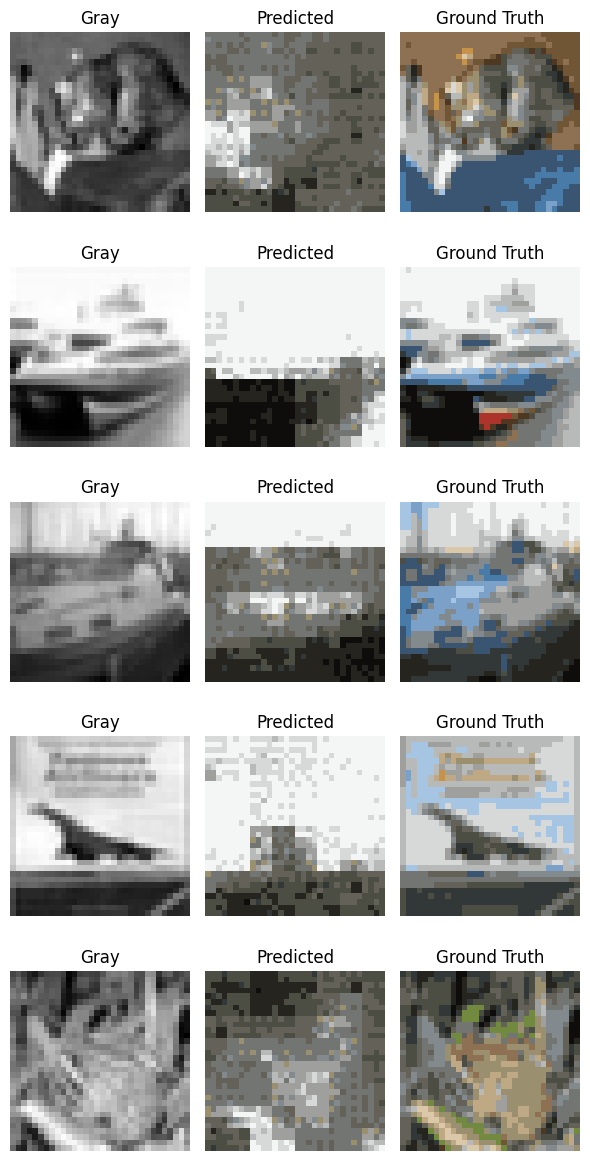

best_val_loss,▁
epoch,▁▁▂▂▂▂▃▃▃▄▄▄▅▅▅▅▆▆▆▇▇▇▇██
train_loss,█▇▇▆▆▅▅▅▄▄▄▃▃▃▃▃▂▂▂▂▂▁▁▁▁
val_loss,█▇▇▇▆▅▅▅▄▄▄▃▃▃▃▃▂▂▂▂▂▂▁▁▁
best_val_loss,2.50624
epoch,25
train_loss,2.51273
val_loss,2.50624


wandb: Sweep Agent: Waiting for job.
wandb: Job received.
wandb: Agent Starting Run: vj204y4n with config:
wandb: 	NF: 8
wandb: 	batch_size: 64
wandb: 	kernel_size: 3
wandb: 	lr: 0.0003
wandb: 	optimizer: sgd
wandb: WARNING Ignored wandb.init() arg project when running a sweep.


Epoch [1/25] | Train Loss: 3.1836 | Val Loss: 3.0853
Epoch [2/25] | Train Loss: 3.0379 | Val Loss: 2.9898
Epoch [3/25] | Train Loss: 2.9644 | Val Loss: 2.9331
Epoch [4/25] | Train Loss: 2.9040 | Val Loss: 2.8714
Epoch [5/25] | Train Loss: 2.8447 | Val Loss: 2.8107
Epoch [6/25] | Train Loss: 2.7880 | Val Loss: 2.7601
Epoch [7/25] | Train Loss: 2.7392 | Val Loss: 2.7137
Epoch [8/25] | Train Loss: 2.6983 | Val Loss: 2.6778
Epoch [9/25] | Train Loss: 2.6646 | Val Loss: 2.6452
Epoch [10/25] | Train Loss: 2.6355 | Val Loss: 2.6182
Epoch [11/25] | Train Loss: 2.6090 | Val Loss: 2.5919
Epoch [12/25] | Train Loss: 2.5840 | Val Loss: 2.5676
Epoch [13/25] | Train Loss: 2.5596 | Val Loss: 2.5446
Epoch [14/25] | Train Loss: 2.5359 | Val Loss: 2.5210
Epoch [15/25] | Train Loss: 2.5123 | Val Loss: 2.4963
Epoch [16/25] | Train Loss: 2.4884 | Val Loss: 2.4720
Epoch [17/25] | Train Loss: 2.4645 | Val Loss: 2.4484
Epoch [18/25] | Train Loss: 2.4420 | Val Loss: 2.4268
Epoch [19/25] | Train Loss: 2.4196 | 

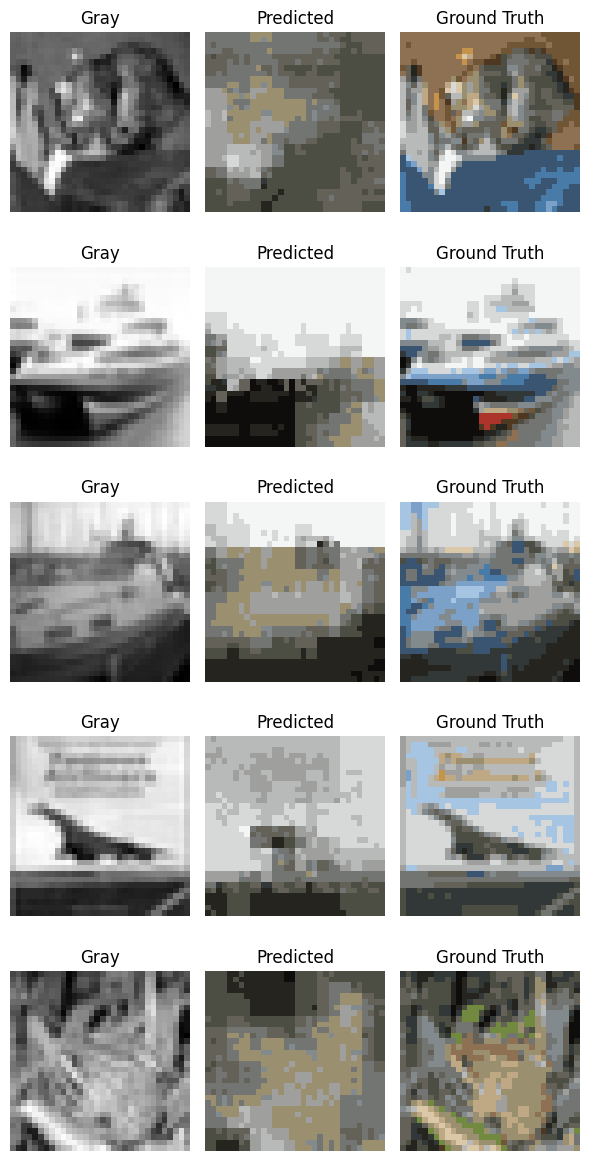

best_val_loss,▁
epoch,▁▁▂▂▂▂▃▃▃▄▄▄▅▅▅▅▆▆▆▇▇▇▇██
train_loss,█▇▆▆▅▅▄▄▄▄▃▃▃▃▃▂▂▂▂▂▂▁▁▁▁
val_loss,█▇▇▆▆▅▅▄▄▄▄▃▃▃▃▃▂▂▂▂▂▁▁▁▁
best_val_loss,2.28734
epoch,25
train_loss,2.30364
val_loss,2.28734


wandb: Agent Starting Run: klj9wig8 with config:
wandb: 	NF: 32
wandb: 	batch_size: 32
wandb: 	kernel_size: 3
wandb: 	lr: 0.0003
wandb: 	optimizer: sgd
wandb: WARNING Ignored wandb.init() arg project when running a sweep.


Epoch [1/25] | Train Loss: 3.1292 | Val Loss: 2.9348
Epoch [2/25] | Train Loss: 2.7867 | Val Loss: 2.6681
Epoch [3/25] | Train Loss: 2.5852 | Val Loss: 2.5064
Epoch [4/25] | Train Loss: 2.4568 | Val Loss: 2.3934
Epoch [5/25] | Train Loss: 2.3645 | Val Loss: 2.3111
Epoch [6/25] | Train Loss: 2.2969 | Val Loss: 2.2508
Epoch [7/25] | Train Loss: 2.2459 | Val Loss: 2.2018
Epoch [8/25] | Train Loss: 2.2075 | Val Loss: 2.1650
Epoch [9/25] | Train Loss: 2.1769 | Val Loss: 2.1311
Epoch [10/25] | Train Loss: 2.1506 | Val Loss: 2.1100
Epoch [11/25] | Train Loss: 2.1287 | Val Loss: 2.0852
Epoch [12/25] | Train Loss: 2.1116 | Val Loss: 2.0646
Epoch [13/25] | Train Loss: 2.0942 | Val Loss: 2.0501
Epoch [14/25] | Train Loss: 2.0837 | Val Loss: 2.0336
Epoch [15/25] | Train Loss: 2.0663 | Val Loss: 2.0195
Epoch [16/25] | Train Loss: 2.0579 | Val Loss: 2.0117
Epoch [17/25] | Train Loss: 2.0445 | Val Loss: 1.9940
Epoch [18/25] | Train Loss: 2.0350 | Val Loss: 1.9840
Epoch [19/25] | Train Loss: 2.0220 | 

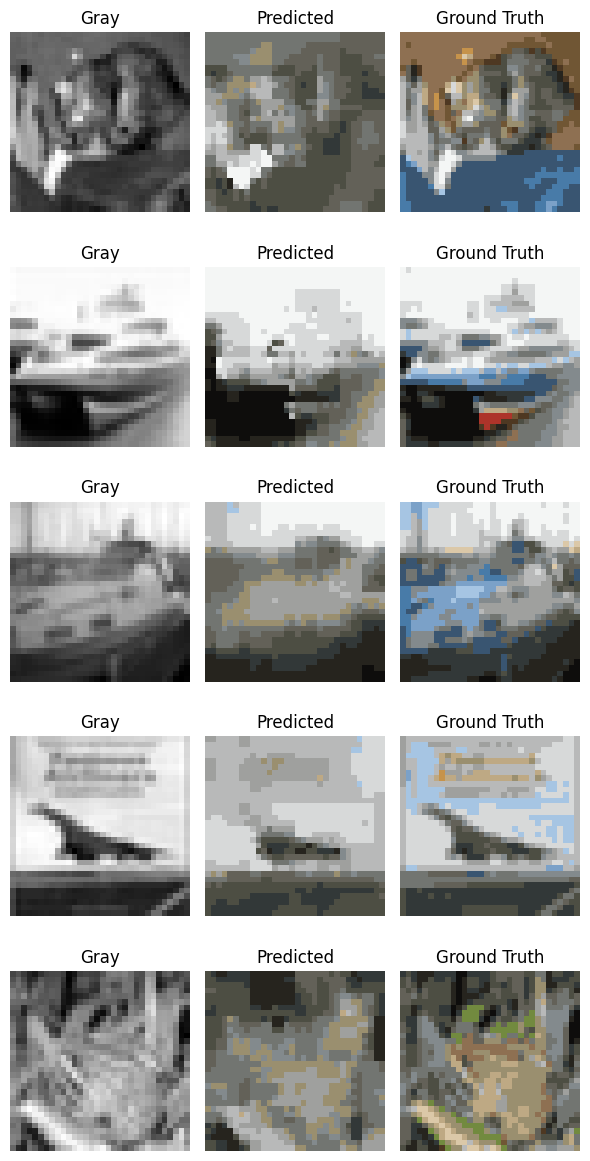

best_val_loss,▁
epoch,▁▁▂▂▂▂▃▃▃▄▄▄▅▅▅▅▆▆▆▇▇▇▇██
train_loss,█▆▅▄▃▃▃▂▂▂▂▂▂▂▂▁▁▁▁▁▁▁▁▁▁
val_loss,█▆▅▄▄▃▃▃▂▂▂▂▂▂▂▂▁▁▁▁▁▁▁▁▁
best_val_loss,1.92216
epoch,25
train_loss,1.97872
val_loss,1.92216


wandb: Agent Starting Run: v7dnpj3k with config:
wandb: 	NF: 8
wandb: 	batch_size: 64
wandb: 	kernel_size: 3
wandb: 	lr: 0.001
wandb: 	optimizer: adam
wandb: WARNING Ignored wandb.init() arg project when running a sweep.


Epoch [1/25] | Train Loss: 2.3159 | Val Loss: 2.0823
Epoch [2/25] | Train Loss: 2.0618 | Val Loss: 2.0075
Epoch [3/25] | Train Loss: 2.0231 | Val Loss: 1.9830
Epoch [4/25] | Train Loss: 2.0016 | Val Loss: 1.9674
Epoch [5/25] | Train Loss: 1.9881 | Val Loss: 1.9599
Epoch [6/25] | Train Loss: 1.9762 | Val Loss: 1.9526
Epoch [7/25] | Train Loss: 1.9686 | Val Loss: 1.9322
Epoch [8/25] | Train Loss: 1.9644 | Val Loss: 1.9189
Epoch [9/25] | Train Loss: 1.9567 | Val Loss: 1.9167
Epoch [10/25] | Train Loss: 1.9523 | Val Loss: 1.9213
Epoch [11/25] | Train Loss: 1.9458 | Val Loss: 1.9071
Epoch [12/25] | Train Loss: 1.9396 | Val Loss: 1.9068
Epoch [13/25] | Train Loss: 1.9404 | Val Loss: 1.9090
Epoch [14/25] | Train Loss: 1.9359 | Val Loss: 1.9012
Epoch [15/25] | Train Loss: 1.9316 | Val Loss: 1.8938
Epoch [16/25] | Train Loss: 1.9308 | Val Loss: 1.8993
Epoch [17/25] | Train Loss: 1.9257 | Val Loss: 1.8882
Epoch [18/25] | Train Loss: 1.9233 | Val Loss: 1.8844
Epoch [19/25] | Train Loss: 1.9198 | 

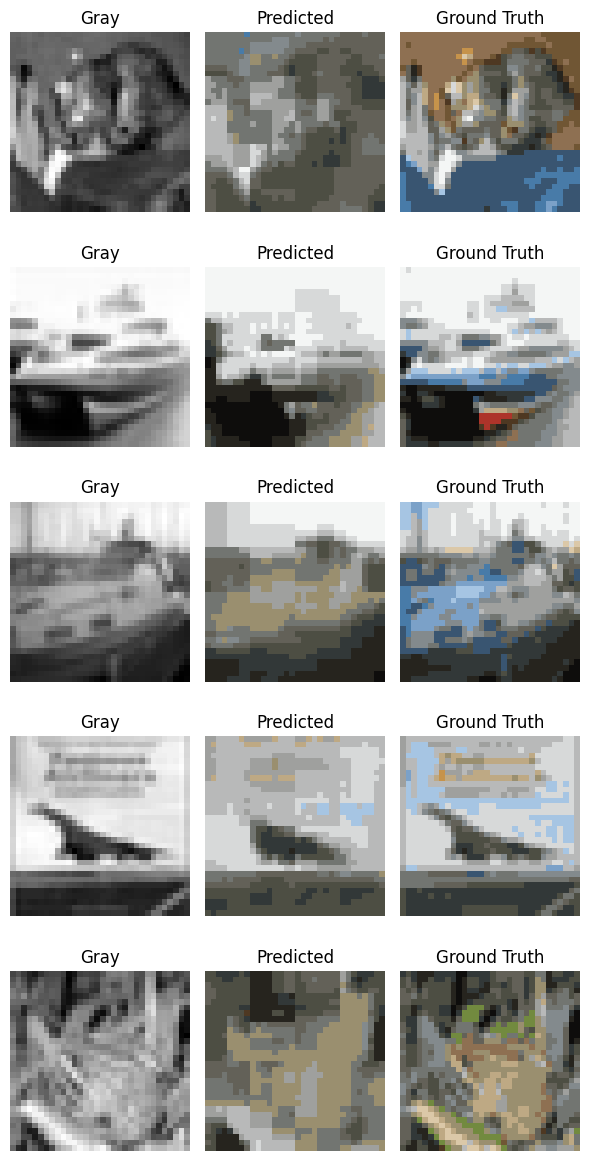

best_val_loss,▁
epoch,▁▁▂▂▂▂▃▃▃▄▄▄▅▅▅▅▆▆▆▇▇▇▇██
train_loss,█▄▃▃▂▂▂▂▂▂▂▂▂▁▁▁▁▁▁▁▁▁▁▁▁
val_loss,█▅▅▄▄▄▃▂▂▃▂▂▂▂▂▂▁▁▁▁▁▂▁▁▁
best_val_loss,1.87614
epoch,25
train_loss,1.91087
val_loss,1.88693


wandb: Sweep Agent: Waiting for job.
wandb: Job received.
wandb: Agent Starting Run: u3la86um with config:
wandb: 	NF: 8
wandb: 	batch_size: 128
wandb: 	kernel_size: 3
wandb: 	lr: 0.0003
wandb: 	optimizer: sgd
wandb: WARNING Ignored wandb.init() arg project when running a sweep.


Epoch [1/25] | Train Loss: 3.2264 | Val Loss: 3.1881
Epoch [2/25] | Train Loss: 3.1549 | Val Loss: 3.1228
Epoch [3/25] | Train Loss: 3.0874 | Val Loss: 3.0513
Epoch [4/25] | Train Loss: 3.0135 | Val Loss: 2.9781
Epoch [5/25] | Train Loss: 2.9431 | Val Loss: 2.9111
Epoch [6/25] | Train Loss: 2.8804 | Val Loss: 2.8541
Epoch [7/25] | Train Loss: 2.8269 | Val Loss: 2.8061
Epoch [8/25] | Train Loss: 2.7821 | Val Loss: 2.7625
Epoch [9/25] | Train Loss: 2.7422 | Val Loss: 2.7247
Epoch [10/25] | Train Loss: 2.7038 | Val Loss: 2.6872
Epoch [11/25] | Train Loss: 2.6657 | Val Loss: 2.6495
Epoch [12/25] | Train Loss: 2.6320 | Val Loss: 2.6162
Epoch [13/25] | Train Loss: 2.6008 | Val Loss: 2.5854
Epoch [14/25] | Train Loss: 2.5715 | Val Loss: 2.5577
Epoch [15/25] | Train Loss: 2.5435 | Val Loss: 2.5292
Epoch [16/25] | Train Loss: 2.5181 | Val Loss: 2.5057
Epoch [17/25] | Train Loss: 2.4940 | Val Loss: 2.4817
Epoch [18/25] | Train Loss: 2.4722 | Val Loss: 2.4617


wandb: Network error (ConnectionError), entering retry loop.


Epoch [19/25] | Train Loss: 2.4522 | Val Loss: 2.4410
Epoch [20/25] | Train Loss: 2.4332 | Val Loss: 2.4236
Epoch [21/25] | Train Loss: 2.4162 | Val Loss: 2.4064


wandb: Network error (ConnectionError), entering retry loop.


Epoch [22/25] | Train Loss: 2.4001 | Val Loss: 2.3908
Epoch [23/25] | Train Loss: 2.3853 | Val Loss: 2.3767
Epoch [24/25] | Train Loss: 2.3720 | Val Loss: 2.3634
Epoch [25/25] | Train Loss: 2.3597 | Val Loss: 2.3512


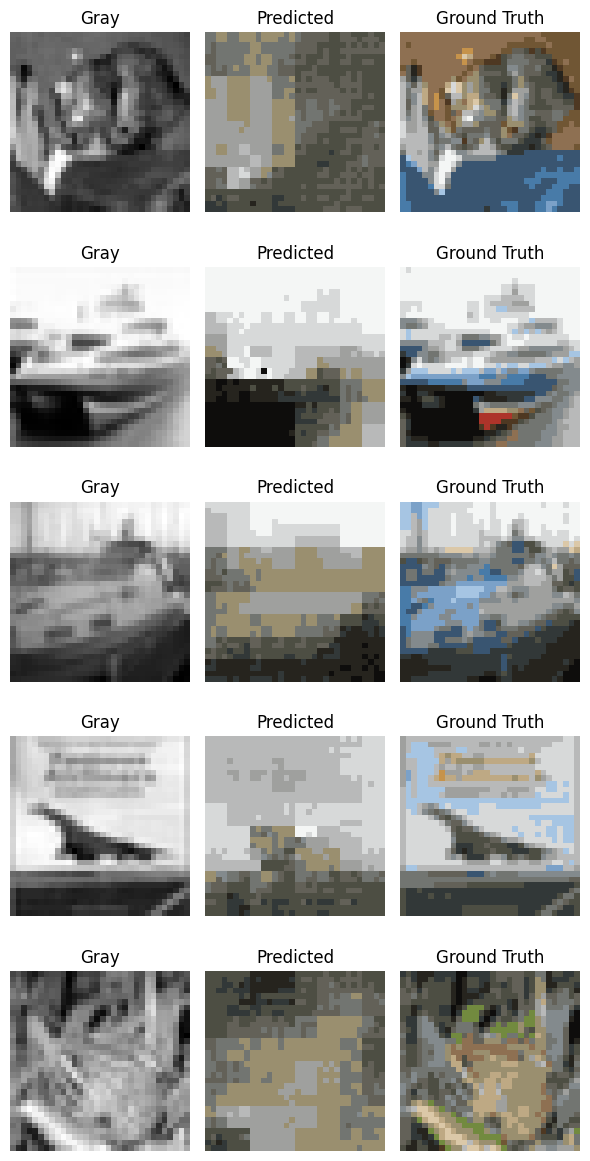

best_val_loss,▁
epoch,▁▁▂▂▂▂▃▃▃▄▄▄▅▅▅▅▆▆▆▇▇▇▇██
train_loss,█▇▇▆▆▅▅▄▄▄▃▃▃▃▂▂▂▂▂▂▁▁▁▁▁
val_loss,█▇▇▆▆▅▅▄▄▄▃▃▃▃▂▂▂▂▂▂▁▁▁▁▁
best_val_loss,2.35116
epoch,25
train_loss,2.3597
val_loss,2.35116


wandb: Agent Starting Run: xqfhhrzx with config:
wandb: 	NF: 32
wandb: 	batch_size: 64
wandb: 	kernel_size: 3
wandb: 	lr: 0.003
wandb: 	optimizer: adam
wandb: WARNING Ignored wandb.init() arg project when running a sweep.


Epoch [1/25] | Train Loss: 1.9857 | Val Loss: 1.8925
Epoch [2/25] | Train Loss: 1.7846 | Val Loss: 1.9592
Epoch [3/25] | Train Loss: 1.7436 | Val Loss: 1.7254
Epoch [4/25] | Train Loss: 1.7224 | Val Loss: 1.7227
Epoch [5/25] | Train Loss: 1.6965 | Val Loss: 1.6654
Epoch [6/25] | Train Loss: 1.6877 | Val Loss: 1.8057
Epoch [7/25] | Train Loss: 1.6716 | Val Loss: 1.6582
Epoch [8/25] | Train Loss: 1.6691 | Val Loss: 1.6393
Epoch [9/25] | Train Loss: 1.6605 | Val Loss: 1.6517
Epoch [10/25] | Train Loss: 1.6562 | Val Loss: 1.6801
Epoch [11/25] | Train Loss: 1.6453 | Val Loss: 1.6045
Epoch [12/25] | Train Loss: 1.6382 | Val Loss: 1.6672
Epoch [13/25] | Train Loss: 1.6312 | Val Loss: 1.6090
Epoch [14/25] | Train Loss: 1.6237 | Val Loss: 1.6365
Epoch [15/25] | Train Loss: 1.6185 | Val Loss: 1.6302
Epoch [16/25] | Train Loss: 1.6160 | Val Loss: 1.6567
Epoch [17/25] | Train Loss: 1.6104 | Val Loss: 1.6863
Epoch [18/25] | Train Loss: 1.6097 | Val Loss: 1.5941
Epoch [19/25] | Train Loss: 1.6009 | 

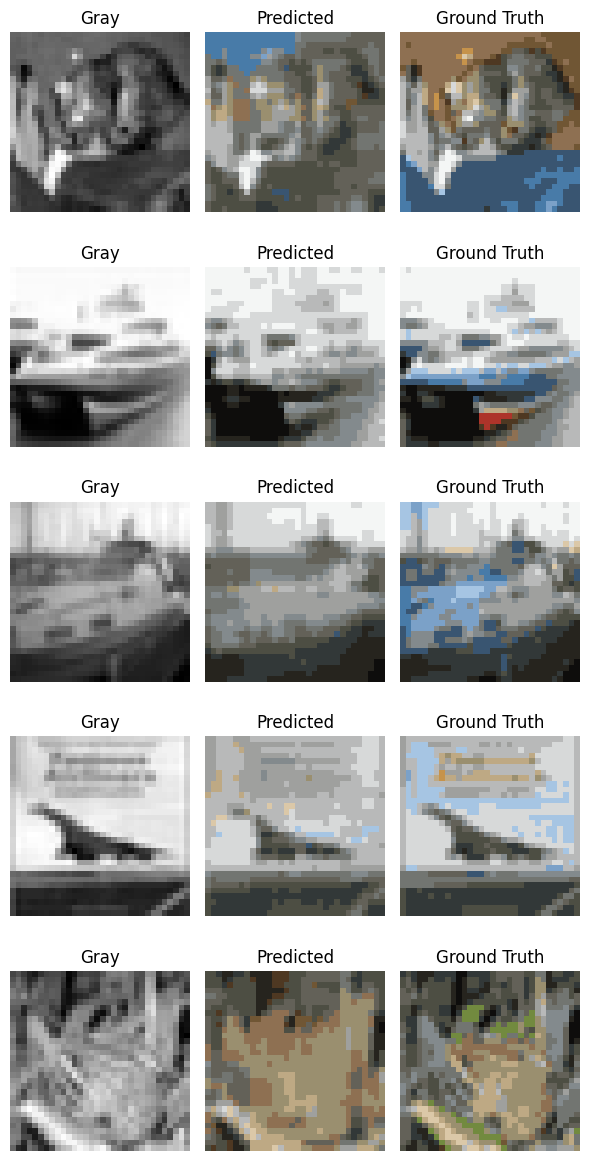

best_val_loss,▁
epoch,▁▁▂▂▂▂▃▃▃▄▄▄▅▅▅▅▆▆▆▇▇▇▇██
train_loss,█▄▄▃▃▃▃▂▂▂▂▂▂▂▂▂▁▁▁▁▁▁▁▁▁
val_loss,▇█▄▃▂▅▂▂▂▃▁▂▁▂▂▂▃▁▂▁▃▂▁▁▁
best_val_loss,1.59406
epoch,25
train_loss,1.5842
val_loss,1.60107


wandb: Agent Starting Run: co8eu75j with config:
wandb: 	NF: 16
wandb: 	batch_size: 64
wandb: 	kernel_size: 3
wandb: 	lr: 0.001
wandb: 	optimizer: adam
wandb: WARNING Ignored wandb.init() arg project when running a sweep.


Epoch [1/25] | Train Loss: 2.1624 | Val Loss: 1.9179
Epoch [2/25] | Train Loss: 1.9171 | Val Loss: 1.8475
Epoch [3/25] | Train Loss: 1.8711 | Val Loss: 1.8354
Epoch [4/25] | Train Loss: 1.8430 | Val Loss: 1.7933
Epoch [5/25] | Train Loss: 1.8271 | Val Loss: 1.8119
Epoch [6/25] | Train Loss: 1.8101 | Val Loss: 1.7724
Epoch [7/25] | Train Loss: 1.8039 | Val Loss: 1.7718
Epoch [8/25] | Train Loss: 1.7958 | Val Loss: 1.7654
Epoch [9/25] | Train Loss: 1.7897 | Val Loss: 1.7693
Epoch [10/25] | Train Loss: 1.7846 | Val Loss: 1.7455
Epoch [11/25] | Train Loss: 1.7757 | Val Loss: 1.7393
Epoch [12/25] | Train Loss: 1.7750 | Val Loss: 1.7812
Epoch [13/25] | Train Loss: 1.7676 | Val Loss: 1.7381
Epoch [14/25] | Train Loss: 1.7641 | Val Loss: 1.7345
Epoch [15/25] | Train Loss: 1.7624 | Val Loss: 1.7253
Epoch [16/25] | Train Loss: 1.7575 | Val Loss: 1.7184
Epoch [17/25] | Train Loss: 1.7589 | Val Loss: 1.7290
Epoch [18/25] | Train Loss: 1.7549 | Val Loss: 1.7480
Epoch [19/25] | Train Loss: 1.7496 | 

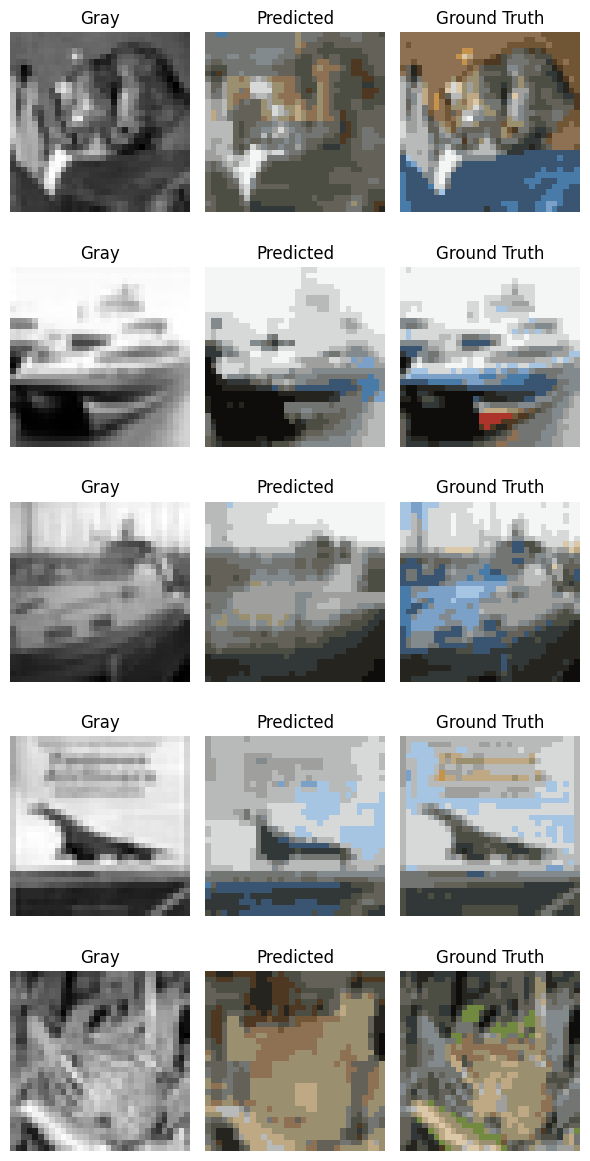

best_val_loss,▁
epoch,▁▁▂▂▂▂▃▃▃▄▄▄▅▅▅▅▆▆▆▇▇▇▇██
train_loss,█▄▃▃▂▂▂▂▂▂▂▂▁▁▁▁▁▁▁▁▁▁▁▁▁
val_loss,█▆▅▄▄▃▃▃▃▂▂▃▂▂▁▁▂▂▁▁▁▃▁▁▁
best_val_loss,1.71096
epoch,25
train_loss,1.73999
val_loss,1.7153


wandb: Sweep Agent: Waiting for job.
wandb: Job received.
wandb: Agent Starting Run: 92rfhhxn with config:
wandb: 	NF: 32
wandb: 	batch_size: 64
wandb: 	kernel_size: 5
wandb: 	lr: 0.003
wandb: 	optimizer: sgd
wandb: WARNING Ignored wandb.init() arg project when running a sweep.


Epoch [1/25] | Train Loss: 2.6984 | Val Loss: 2.3704
Epoch [2/25] | Train Loss: 2.2235 | Val Loss: 2.0911
Epoch [3/25] | Train Loss: 2.0375 | Val Loss: 1.9746
Epoch [4/25] | Train Loss: 1.9363 | Val Loss: 1.8776
Epoch [5/25] | Train Loss: 1.8738 | Val Loss: 1.8136
Epoch [6/25] | Train Loss: 1.8277 | Val Loss: 1.7931
Epoch [7/25] | Train Loss: 1.7889 | Val Loss: 1.7362
Epoch [8/25] | Train Loss: 1.7577 | Val Loss: 1.7043
Epoch [9/25] | Train Loss: 1.7279 | Val Loss: 1.6838
Epoch [10/25] | Train Loss: 1.7060 | Val Loss: 1.6655
Epoch [11/25] | Train Loss: 1.6783 | Val Loss: 1.6433
Epoch [12/25] | Train Loss: 1.6649 | Val Loss: 1.6781
Epoch [13/25] | Train Loss: 1.6444 | Val Loss: 1.6000
Epoch [14/25] | Train Loss: 1.6284 | Val Loss: 1.5788
Epoch [15/25] | Train Loss: 1.6088 | Val Loss: 1.5709
Epoch [16/25] | Train Loss: 1.6018 | Val Loss: 1.5567
Epoch [17/25] | Train Loss: 1.5909 | Val Loss: 1.5714
Epoch [18/25] | Train Loss: 1.5796 | Val Loss: 1.5732
Epoch [19/25] | Train Loss: 1.5721 | 

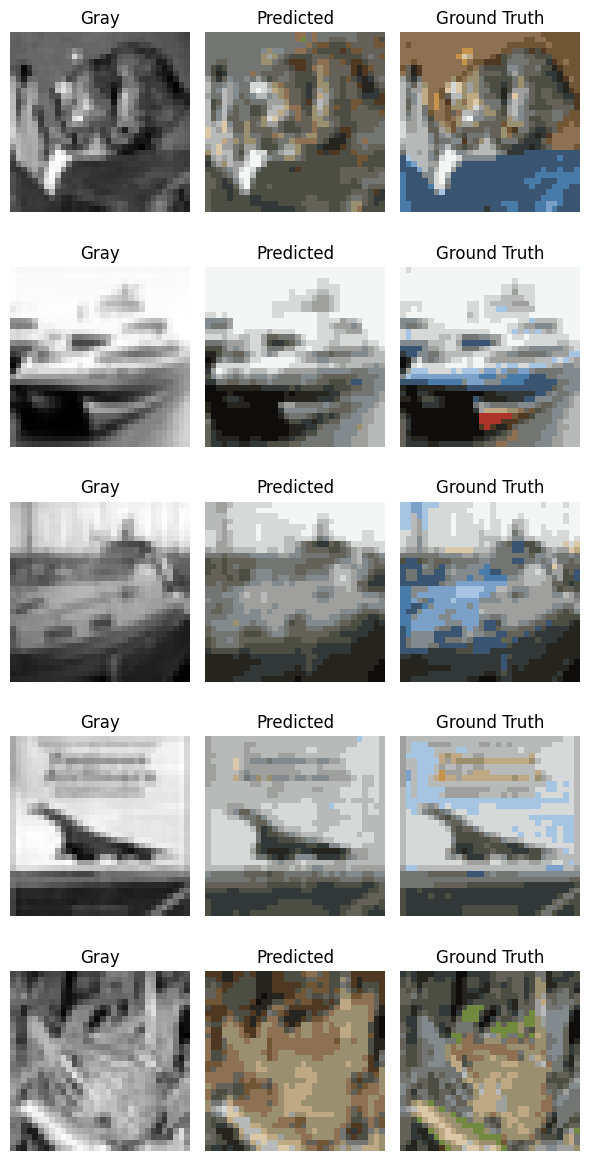

best_val_loss,▁
epoch,▁▁▂▂▂▂▃▃▃▄▄▄▅▅▅▅▆▆▆▇▇▇▇██
train_loss,█▅▄▃▃▃▃▂▂▂▂▂▂▂▁▁▁▁▁▁▁▁▁▁▁
val_loss,█▆▅▄▄▃▃▃▂▂▂▂▂▂▂▁▂▂▂▁▂▁▁▁▁
best_val_loss,1.50035
epoch,25
train_loss,1.53123
val_loss,1.50035


wandb: Agent Starting Run: wyd190o6 with config:
wandb: 	NF: 32
wandb: 	batch_size: 128
wandb: 	kernel_size: 5
wandb: 	lr: 0.0003
wandb: 	optimizer: adam
wandb: WARNING Ignored wandb.init() arg project when running a sweep.


Epoch [1/25] | Train Loss: 2.5472 | Val Loss: 2.1355
Epoch [2/25] | Train Loss: 1.9717 | Val Loss: 1.8406
Epoch [3/25] | Train Loss: 1.7875 | Val Loss: 1.7152
Epoch [4/25] | Train Loss: 1.6894 | Val Loss: 1.6425
Epoch [5/25] | Train Loss: 1.6298 | Val Loss: 1.5972
Epoch [6/25] | Train Loss: 1.5993 | Val Loss: 1.5614
Epoch [7/25] | Train Loss: 1.5707 | Val Loss: 1.5486
Epoch [8/25] | Train Loss: 1.5490 | Val Loss: 1.5310
Epoch [9/25] | Train Loss: 1.5341 | Val Loss: 1.5370
Epoch [10/25] | Train Loss: 1.5230 | Val Loss: 1.5004
Epoch [11/25] | Train Loss: 1.5097 | Val Loss: 1.4876
Epoch [12/25] | Train Loss: 1.5043 | Val Loss: 1.4888
Epoch [13/25] | Train Loss: 1.4939 | Val Loss: 1.4734
Epoch [14/25] | Train Loss: 1.4858 | Val Loss: 1.4676
Epoch [15/25] | Train Loss: 1.4762 | Val Loss: 1.4900
Epoch [16/25] | Train Loss: 1.4697 | Val Loss: 1.4434
Epoch [17/25] | Train Loss: 1.4641 | Val Loss: 1.4372
Epoch [18/25] | Train Loss: 1.4575 | Val Loss: 1.4463
Epoch [19/25] | Train Loss: 1.4568 | 

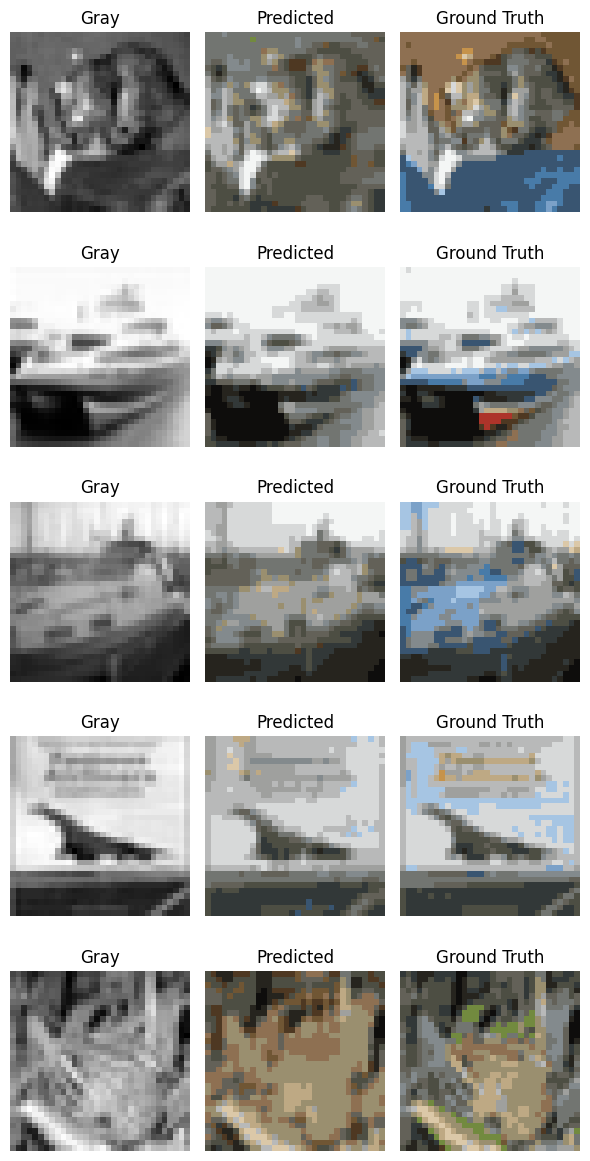

best_val_loss,▁
epoch,▁▁▂▂▂▂▃▃▃▄▄▄▅▅▅▅▆▆▆▇▇▇▇██
train_loss,█▄▃▃▂▂▂▂▂▂▂▁▁▁▁▁▁▁▁▁▁▁▁▁▁
val_loss,█▅▄▃▃▂▂▂▂▂▂▂▂▁▂▁▁▁▁▂▁▁▁▁▁
best_val_loss,1.42161
epoch,25
train_loss,1.4274
val_loss,1.44313


wandb: Sweep Agent: Waiting for job.
wandb: Job received.
wandb: Agent Starting Run: j17fllcz with config:
wandb: 	NF: 16
wandb: 	batch_size: 128
wandb: 	kernel_size: 5
wandb: 	lr: 0.003
wandb: 	optimizer: adam
wandb: WARNING Ignored wandb.init() arg project when running a sweep.


Epoch [1/25] | Train Loss: 2.0901 | Val Loss: 1.8763
Epoch [2/25] | Train Loss: 1.7597 | Val Loss: 1.7436
Epoch [3/25] | Train Loss: 1.6971 | Val Loss: 2.1506
Epoch [4/25] | Train Loss: 1.6605 | Val Loss: 1.6472
Epoch [5/25] | Train Loss: 1.6385 | Val Loss: 1.6224
Epoch [6/25] | Train Loss: 1.6161 | Val Loss: 1.6066
Epoch [7/25] | Train Loss: 1.5949 | Val Loss: 1.6408
Epoch [8/25] | Train Loss: 1.5883 | Val Loss: 1.7170
Epoch [9/25] | Train Loss: 1.5755 | Val Loss: 1.5512
Epoch [10/25] | Train Loss: 1.5636 | Val Loss: 1.6170
Epoch [11/25] | Train Loss: 1.5588 | Val Loss: 1.5763
Epoch [12/25] | Train Loss: 1.5547 | Val Loss: 1.6617
Epoch [13/25] | Train Loss: 1.5430 | Val Loss: 1.5376
Epoch [14/25] | Train Loss: 1.5459 | Val Loss: 1.5354
Epoch [15/25] | Train Loss: 1.5401 | Val Loss: 1.5278
Epoch [16/25] | Train Loss: 1.5322 | Val Loss: 1.5427
Epoch [17/25] | Train Loss: 1.5308 | Val Loss: 1.5295
Epoch [18/25] | Train Loss: 1.5231 | Val Loss: 1.5005
Epoch [19/25] | Train Loss: 1.5236 | 

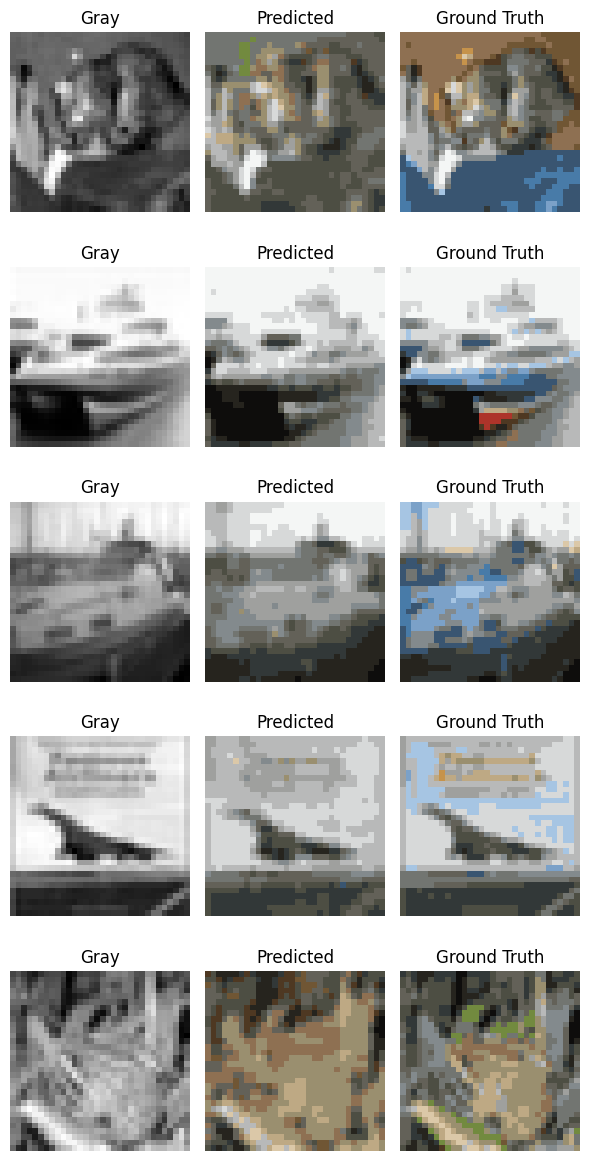

best_val_loss,▁
epoch,▁▁▂▂▂▂▃▃▃▄▄▄▅▅▅▅▆▆▆▇▇▇▇██
train_loss,█▄▃▃▃▂▂▂▂▂▂▂▁▂▁▁▁▁▁▁▁▁▁▁▁
val_loss,▅▄█▃▂▂▃▃▂▂▂▃▂▁▁▂▁▁▁▂▁▁▃▁▁
best_val_loss,1.48964
epoch,25
train_loss,1.5025
val_loss,1.48964


wandb: Agent Starting Run: 32vu7dny with config:
wandb: 	NF: 16
wandb: 	batch_size: 128
wandb: 	kernel_size: 5
wandb: 	lr: 0.001
wandb: 	optimizer: sgd
wandb: WARNING Ignored wandb.init() arg project when running a sweep.


Epoch [1/25] | Train Loss: 3.1513 | Val Loss: 3.0326
Epoch [2/25] | Train Loss: 2.9325 | Val Loss: 2.8364
Epoch [3/25] | Train Loss: 2.7500 | Val Loss: 2.6753
Epoch [4/25] | Train Loss: 2.6138 | Val Loss: 2.5590
Epoch [5/25] | Train Loss: 2.5098 | Val Loss: 2.4662
Epoch [6/25] | Train Loss: 2.4268 | Val Loss: 2.3893
Epoch [7/25] | Train Loss: 2.3590 | Val Loss: 2.3278
Epoch [8/25] | Train Loss: 2.3051 | Val Loss: 2.2786
Epoch [9/25] | Train Loss: 2.2596 | Val Loss: 2.2354
Epoch [10/25] | Train Loss: 2.2205 | Val Loss: 2.2010
Epoch [11/25] | Train Loss: 2.1878 | Val Loss: 2.1674
Epoch [12/25] | Train Loss: 2.1585 | Val Loss: 2.1385
Epoch [13/25] | Train Loss: 2.1316 | Val Loss: 2.1148
Epoch [14/25] | Train Loss: 2.1075 | Val Loss: 2.0970
Epoch [15/25] | Train Loss: 2.0867 | Val Loss: 2.0685
Epoch [16/25] | Train Loss: 2.0652 | Val Loss: 2.0490
Epoch [17/25] | Train Loss: 2.0493 | Val Loss: 2.0358
Epoch [18/25] | Train Loss: 2.0292 | Val Loss: 2.0133
Epoch [19/25] | Train Loss: 2.0144 | 

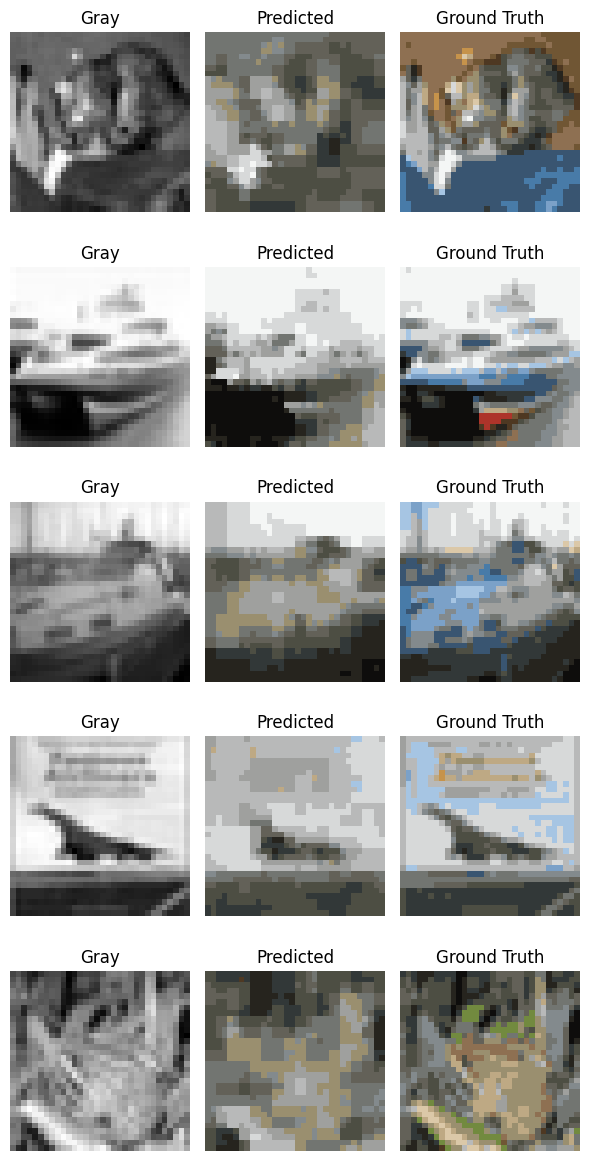

best_val_loss,▁
epoch,▁▁▂▂▂▂▃▃▃▄▄▄▅▅▅▅▆▆▆▇▇▇▇██
train_loss,█▇▆▅▄▄▃▃▃▃▂▂▂▂▂▂▂▂▁▁▁▁▁▁▁
val_loss,█▇▆▅▄▄▄▃▃▃▃▂▂▂▂▂▂▂▂▁▁▁▁▁▁
best_val_loss,1.90959
epoch,25
train_loss,1.93171
val_loss,1.90959


wandb: Agent Starting Run: 27ggeyiq with config:
wandb: 	NF: 16
wandb: 	batch_size: 64
wandb: 	kernel_size: 5
wandb: 	lr: 0.0001
wandb: 	optimizer: sgd
wandb: WARNING Ignored wandb.init() arg project when running a sweep.


Epoch [1/25] | Train Loss: 3.2505 | Val Loss: 3.2235
Epoch [2/25] | Train Loss: 3.2029 | Val Loss: 3.1847
Epoch [3/25] | Train Loss: 3.1682 | Val Loss: 3.1533
Epoch [4/25] | Train Loss: 3.1386 | Val Loss: 3.1245
Epoch [5/25] | Train Loss: 3.1095 | Val Loss: 3.0944
Epoch [6/25] | Train Loss: 3.0780 | Val Loss: 3.0605
Epoch [7/25] | Train Loss: 3.0422 | Val Loss: 3.0211
Epoch [8/25] | Train Loss: 3.0033 | Val Loss: 2.9828
Epoch [9/25] | Train Loss: 2.9655 | Val Loss: 2.9462
Epoch [10/25] | Train Loss: 2.9315 | Val Loss: 2.9142
Epoch [11/25] | Train Loss: 2.9012 | Val Loss: 2.8824
Epoch [12/25] | Train Loss: 2.8736 | Val Loss: 2.8568
Epoch [13/25] | Train Loss: 2.8474 | Val Loss: 2.8306
Epoch [14/25] | Train Loss: 2.8223 | Val Loss: 2.8071
Epoch [15/25] | Train Loss: 2.7977 | Val Loss: 2.7838
Epoch [16/25] | Train Loss: 2.7730 | Val Loss: 2.7579
Epoch [17/25] | Train Loss: 2.7485 | Val Loss: 2.7329
Epoch [18/25] | Train Loss: 2.7240 | Val Loss: 2.7060
Epoch [19/25] | Train Loss: 2.6990 | 

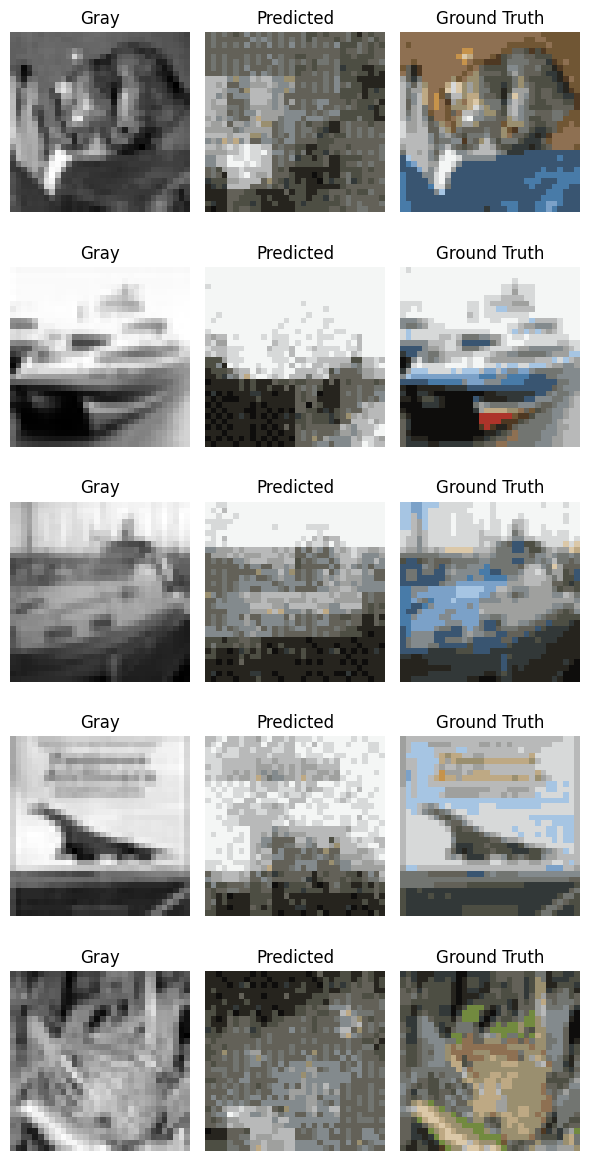

best_val_loss,▁
epoch,▁▁▂▂▂▂▃▃▃▄▄▄▅▅▅▅▆▆▆▇▇▇▇██
train_loss,██▇▇▇▆▆▅▅▅▄▄▄▄▃▃▃▃▂▂▂▂▁▁▁
val_loss,██▇▇▇▆▆▅▅▅▄▄▄▄▃▃▃▃▂▂▂▂▁▁▁
best_val_loss,2.55395
epoch,25
train_loss,2.56344
val_loss,2.55395


: 

In [ ]:

sweep_config = {
    "method": "random",
    "metric": {"name": "val_loss", "goal": "minimize"},
    "parameters": {
        "lr": {"values": [1e-4, 3e-4, 1e-3, 3e-3]},
        "batch_size": {"values": [32, 64, 128]},
        "NF": {"values": [8, 16, 32]},
        "kernel_size": {"values": [3, 5]},
        "optimizer": {"values": ["adam", "sgd"]},
    },
}

sweep_id = wandb.sweep(sweep_config, project="_image-colourisation-cifar10")
wandb.agent(sweep_id, function=train, count=20)